In [9]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 

# Define path that contains some junction files (only 2 files are used for this example, corresponding to 2 individual cells)
juncs_path = "/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/Leaflet/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

The junctions are loaded from the following path: /commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/Leaflet/
The files in the path are: ['astrocytes_bulk_intron_clusters_50_500000_5_20240429_bulk.gz', 'astrocytes_bulk_juncs.bed', 'SRR2557112_junctions.bed']


In [22]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.clustering.find_intron_clusters import read_junction_files

# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = juncs_path

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/reference-genome/MM10-PLUS/genes/gencode.vM10.annotation.gtf" 

# define additional parameters 
sequencing_type = "bulk"

output_path = "/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/Leaflet/"
# ensure output files are to be saved in output_path 
output_file =  output_path + "astrocytes_bulk_intron_clusters"
junc_bed_file= output_path + "astrocytes_bulk_juncs.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*_junctions.bed" # depends on how you ran regtools 

In [23]:
junc_files

'/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/Leaflet/'

In [24]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons, min_num_cells_wjunc=1, 
                       junc_suffix=junc_suffix, filter_shared_ss=False,
                       run_notebook = True)

Loading files obtained from bulk sequencing


100%|██████████| 1/1 [00:00<00:00,  3.62it/s]


The gtf file you provided is /commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/reference-genome/MM10-PLUS/genes/gencode.vM10.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_status', 'gene_name', 'level', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_status', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 87.43 seconds
The number of unique exons is 395916
The number of unique transcript ids is 116181
The number of unique gene ids is 48440
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Cleaning up 'chrom' column
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 101351
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 95297
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 89096
The number of junctions after removing singletons is 9424
The number of clusters after removing singletons is 3223
The number of junctions after gtf file mapping 9424
The number of clusters after filtering for shared splice sites is 3223
The number of junctions after filtering for shared splice sites is 9424
Refining intron clusters to account for junction usage r

In [13]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
2111     1      40004.913    40006.670      +           1757            41   
2112     1      40004.913    40006.673      +           1760            10   

        Start_b      End_b               exon_id  
2111  40004.806  40004.913  ENSMUSE00000630182.1  
2112  40004.806  40004.913  ENSMUSE00000630182.1  
The junction of interest is 1_40004913_40006670


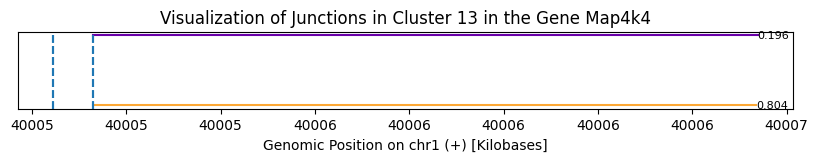

In [21]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [15]:
all_juncs_df

,junction_id,counts_total,chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,...,block_add_start,block_subtract_end,intron_length,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,gene_id,Count
0,10_108251944_108252756,21,10,108251944,108252756,JUNC00014158,21,+,108251839,108252898,...,105,142,812,35,21,0.600000,1.000000,963,ENSMUSG00000019907.9,3
1,10_108251944_108253324,14,10,108251944,108253324,JUNC00014157,14,+,108251839,108253463,...,105,139,1380,35,22,0.400000,0.636364,963,ENSMUSG00000019907.9,3
2,10_108252924_108253324,8,10,108252924,108253324,JUNC00014160,8,+,108252781,108253424,...,143,100,400,8,22,1.000000,0.363636,963,ENSMUSG00000019907.9,3
3,10_108636664_108642213,7,10,108636664,108642213,JUNC00014180,7,-,108636550,108642323,...,114,110,5549,7,13,1.000000,0.538462,1021,ENSMUSG00000035864.14,2
4,10_108636673_108642213,6,10,108636673,108642213,JUNC00014181,6,-,108636550,108642349,...,123,136,5540,6,13,1.000000,0.461538,1021,ENSMUSG00000035864.14,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4593,Y_1012169_1013378,15,Y,1012169,1013378,JUNC00139681,15,+,1012047,1013473,...,122,95,1209,26,15,0.576923,1.000000,1714,ENSMUSG00000069049.11,3
4594,Y_1012169_1014633,11,Y,1012169,1014633,JUNC00139680,11,+,1012047,1014748,...,122,115,2464,26,24,0.423077,0.458333,1714,ENSMUSG00000069049.11,3
4595,Y_1013473_1014633,13,Y,1013473,1014633,JUNC00139682,13,+,1013376,1014759,...,97,126,1160,13,24,1.000000,0.541667,1714,ENSMUSG00000069049.11,3
4596,Y_1168185_1169964,13,Y,1168185,1169964,JUNC00139716,13,-,1168089,1170091,...,96,127,1779,13,24,1.000000,0.541667,1715,ENSMUSG00000068457.14,2


In [16]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = all_juncs_df.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 2.773220747889023
